# Notebook 06 — Exploratory Data Analysis for Customer Churn

## Objective

This notebook analyzes the profiles and characteristics associated with customer churn.

The analysis focuses on:

- target distribution;
- demographic characteristics;
- account portfolio;
- financial behavior;
- product ownership;
- KYC and compliance;
- banking relationship;
- business insights.

No model is trained in this notebook.

In [1]:
# ==========================================================
# 6.1 IMPORTS AND CONFIGURATION
# ==========================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", None)

print("=" * 70)
print("NOTEBOOK 06 — EXPLORATORY DATA ANALYSIS")
print("=" * 70)

NOTEBOOK 06 — EXPLORATORY DATA ANALYSIS


In [2]:
# ==========================================================
# 6.2 PATHS AND DATA LOADING
# ==========================================================

PROJECT_ROOT = Path.cwd().parent

INPUT_FILE = (
    PROJECT_ROOT
    / "data"
    / "model"
    / "customer_model_dataset.csv"
)

FIGURES_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "figures"
    / "06_eda"
)

TABLES_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "tables"
)

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

if not INPUT_FILE.exists():
    raise FileNotFoundError(
        f"Model dataset not found: {INPUT_FILE}"
    )

df = pd.read_csv(
    INPUT_FILE,
    low_memory=False
)

print("=" * 70)
print("MODEL DATASET LOADED")
print("=" * 70)
print(f"Location : {INPUT_FILE.resolve()}")
print(f"Rows     : {df.shape[0]:,}")
print(f"Columns  : {df.shape[1]}")

MODEL DATASET LOADED
Location : C:\Users\Sarra\OneDrive\Desktop\PFE_CHURN_ESB\data\model\customer_model_dataset.csv
Rows     : 363,569
Columns  : 92


In [3]:
# ==========================================================
# 6.3 INITIAL DATASET VALIDATION
# ==========================================================

required_columns = [
    "CUSTOMER_NO",
    "TARGET_CHURN"
]

missing_required_columns = [
    column
    for column in required_columns
    if column not in df.columns
]

if missing_required_columns:
    raise ValueError(
        f"Missing required columns: {missing_required_columns}"
    )

print("=" * 70)
print("DATASET VALIDATION")
print("=" * 70)

print(
    "Duplicate customers:",
    df["CUSTOMER_NO"].duplicated().sum()
)

print(
    "Missing CUSTOMER_NO:",
    df["CUSTOMER_NO"].isna().sum()
)

print(
    "Missing TARGET_CHURN:",
    df["TARGET_CHURN"].isna().sum()
)

print(
    "Target values:",
    sorted(df["TARGET_CHURN"].dropna().unique().tolist())
)

assert df["CUSTOMER_NO"].duplicated().sum() == 0
assert df["CUSTOMER_NO"].isna().sum() == 0
assert df["TARGET_CHURN"].isna().sum() == 0
assert set(df["TARGET_CHURN"].unique()).issubset({0, 1})

print("\nInitial validation successful.")

display(df.head())

DATASET VALIDATION
Duplicate customers: 0
Missing CUSTOMER_NO: 0
Missing TARGET_CHURN: 0
Target values: [0, 1]

Initial validation successful.


,CUSTOMER_NO,ACCOUNT_NO,NATIONALITY,RESIDENCE,MARITAL_STATUS,CUST_OPENING_DATE,DATE_OF_BIRTH,NATURE_CLIENT,BRANCH,SCORE_KYC,COMPLETED_FILE,LAST_REVIEW_DATE,NEXT__REVIEW_DATE,ACCOUNT_STATUS,ACCT_OPENING_DATE,ACCOUNT_CATEGORY,ACCOUNT_TYPE_DESC,CURRENCY,ACCT_CLOSE_DATE,CLOSURE_REASON,ACCT_BALANCE,INDUSTRY,SALARY,PRODUCT_GROUP,PRODUCT_LINE,PRODUCT,ACCOUNTNATURE,STARTDATE,MATURITYDATE,AMOUNT,FIXEDRATE,PRODUCT_STATUS,PARTYCLASS,LOB,AGE,AGE_GROUP,CUSTOMER_TENURE_YEARS,IS_TUNISIAN,IS_RESIDENT,CUSTOMER_SEGMENT,MARITAL_STATUS_GROUP,NB_ACCOUNTS,ACTIVE_ACCOUNTS,CLOSED_ACCOUNTS,TOTAL_BALANCE,AVG_BALANCE,MAX_BALANCE,MIN_BALANCE,ACCOUNT_DIVERSITY,HAS_MULTIPLE_ACCOUNTS,HAS_ACTIVE_ACCOUNT,HAS_CLOSED_ACCOUNT,ACTIVE_ACCOUNT_RATIO,HAS_POSITIVE_SALARY,HAS_POSITIVE_BALANCE,HAS_NEGATIVE_BALANCE,HAS_ZERO_TOTAL_BALANCE,HIGH_VALUE_CUSTOMER,SALARY_LEVEL,BALANCE_LEVEL,BALANCE_TO_SALARY_RATIO,NB_PRODUCTS,NB_PRODUCT_GROUPS,NB_PRODUCT_LINES,HAS_LOAN,HAS_SAVINGS,HAS_DEPOSIT,HAS_CURRENT_ACCOUNT,PRODUCT_DIVERSITY,KYC_RISK_LEVEL,FILE_COMPLETED_FLAG,LOW_KYC_RISK,MEDIUM_KYC_RISK,HIGH_KYC_RISK,VERY_HIGH_KYC_RISK,DAYS_SINCE_LAST_REVIEW,DAYS_TO_NEXT_REVIEW,REVIEW_OVERDUE,HAS_REVIEW_HISTORY,HAS_NEXT_REVIEW_DATE,REVIEW_STATUS,NB_BRANCHES,NB_INDUSTRIES,NB_LOB,NB_CURRENCIES,MAIN_BRANCH,MAIN_INDUSTRY,MAIN_LOB,MAIN_CURRENCY,IS_MULTI_BRANCH,IS_MULTI_CURRENCY,TARGET_CHURN
0,112872078,2.010326e+09,TN,TN,UNKNOWN,NaN,NaN,UNKNOWN,5801,H2,UNKNOWN,2023-09-22,2025-09-21,Active,2023-02-27,8902.0,AVA ATB,TND,NaN,NOT_APPLICABLE,589747.163,1814,612.0,NOT_APPLICABLE,NOT_APPLICABLE,NOT_APPLICABLE,AVA ATB,NaN,NaN,NaN,NaN,NOT_APPLICABLE,Corporate,30,NaN,NaN,NaN,1,1,Corporate,UNKNOWN,59,59,0,748225.554,12681.789051,2833259.331,-1641095.767,17,1,1,0,1.0,1,1,1,0,1,LOW,VERY_HIGH,1222.590775,0,0,0,0,0,0,0,0,H2,0,0,0,1,1,881.0,-151.0,1,1,1,OVERDUE,1,1,1,3,5801,1814,30,TND,0,1,0
1,112872083,2.011459e+09,TN,TN,UNKNOWN,NaN,NaN,UNKNOWN,11,LR,UNKNOWN,NaN,NaN,Active,2025-12-31,8014.0,COMPTE BROKER,TND,NaN,NOT_APPLICABLE,0.000,3100,612.0,NOT_APPLICABLE,NOT_APPLICABLE,NOT_APPLICABLE,COMPTE BROKER,NaN,NaN,NaN,NaN,NOT_APPLICABLE,Corporate,30,NaN,NaN,NaN,1,1,Corporate,UNKNOWN,14,14,0,0.000,0.000000,0.000,0.000,2,1,1,0,1.0,1,0,0,1,0,LOW,ZERO,0.000000,0,0,0,0,0,0,0,0,LR,0,1,0,0,0,NaN,NaN,0,0,0,UNKNOWN,1,1,1,1,11,3100,30,TND,0,0,0
2,113072080,2.010915e+09,TN,TN,UNKNOWN,NaN,NaN,PM,5802,MR,UNKNOWN,NaN,NaN,Active,2025-02-03,8930.0,DEPOT A TERME CLIENT NON ATB,TND,NaN,NOT_APPLICABLE,0.000,111,612.0,NOT_APPLICABLE,NOT_APPLICABLE,NOT_APPLICABLE,DEPOT A TERME CLIENT NON ATB,NaN,NaN,NaN,NaN,NOT_APPLICABLE,Corporate,13,NaN,NaN,NaN,1,1,Corporate,UNKNOWN,2,2,0,0.000,0.000000,0.000,0.000,1,1,1,0,1.0,1,0,0,1,0,LOW,ZERO,0.000000,0,0,0,0,0,1,0,0,MR,0,0,1,0,0,NaN,NaN,0,0,0,UNKNOWN,1,1,1,2,5802,111,13,TDC,0,1,0
3,113073073,2.001489e+09,TN,TN,C,2020-10-08,2002-02-20,PPH,5890,LR,YES,2024-09-25,2028-09-24,Closed,NaN,NaN,NOT_APPLICABLE,NOT_APPLICABLE,2024-12-04,ATB.REASON.13,NaN,9000,400.0,NOT_APPLICABLE,NOT_APPLICABLE,NOT_APPLICABLE,NOT_APPLICABLE,NaN,NaN,NaN,NaN,NOT_APPLICABLE,Retail,4,24.0,18-25,5.4,1,1,Retail,C,1,0,1,0.000,0.000000,0.000,0.000,0,0,0,1,0.0,1,0,0,1,0,LOW,ZERO,0.000000,0,0,0,0,0,0,0,0,LR,1,1,0,0,0,512.0,948.0,0,1,1,PLANNED_LATER,1,1,1,0,5890,9000,4,UNKNOWN,0,0,1
4,113073074,2.003284e+09,TN,TN,M,2020-10-08,1977-08-17,PPH,5890,LR,YES,2025-08-06,2029-08-05,Active,2020-10-08,6001.0,Comptes Spéciaux d épargne,TND,NaN,NOT_APPLICABLE,2001.000,9000,600.0,ATB.GRP.EPARGNE.ACCT,ACCOUNTS,ATB.EPARG.ACCT.SPECIAUX,Comptes Spéciaux d épargne,NaN,NaN,2001.0,NaN,NOT_APPLICABLE,Retail,4,49.0,46-55,5.4,1,1,Retail,M,1,1,0,2001.000,2001.000000,2001.000,2001.000,1,0,1,0,1.0,1,1,0,0,0,LOW,MEDIUM,3.335000,1,1,1,0,1,0,0,3,LR,1,1,0,0,0,197.0,1263.0,0,1,1,PLANNED_LATER,1,1,1,1,5890,9000,4,TND,0,0,0


In [4]:
# ==========================================================
# 6.4 TARGET DISTRIBUTION
# ==========================================================

target_summary = (
    df["TARGET_CHURN"]
    .value_counts()
    .sort_index()
    .rename_axis("TARGET_CHURN")
    .reset_index(name="CUSTOMERS")
)

target_summary["CLASS"] = [
    "Non Churn",
    "Churn"
]

target_summary["PERCENTAGE"] = (
    target_summary["CUSTOMERS"]
    / len(df)
    * 100
).round(2)

target_summary = target_summary[
    [
        "CLASS",
        "CUSTOMERS",
        "PERCENTAGE"
    ]
]

print("=" * 70)
print("TARGET DISTRIBUTION")
print("=" * 70)

display(target_summary)

TARGET DISTRIBUTION


,CLASS,CUSTOMERS,PERCENTAGE
0,Non Churn,246211,67.72
1,Churn,117358,32.28


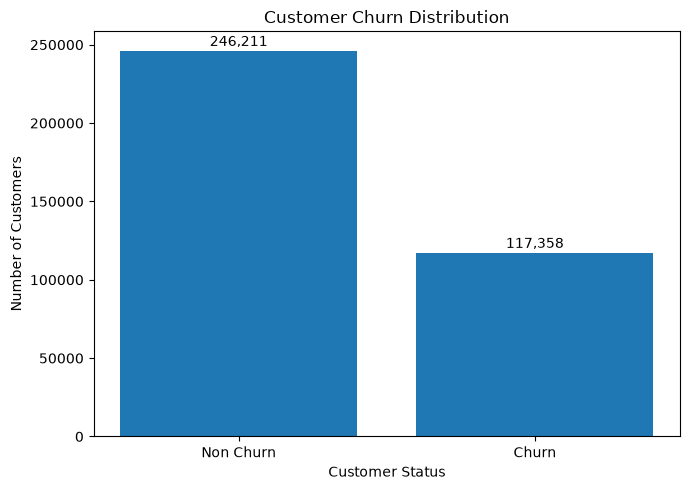

In [5]:
plt.figure(figsize=(7,5))

counts = df["TARGET_CHURN"].value_counts().sort_index()

plt.bar(
    ["Non Churn","Churn"],
    counts.values
)

plt.title("Customer Churn Distribution")

plt.xlabel("Customer Status")

plt.ylabel("Number of Customers")

for i,v in enumerate(counts.values):
    plt.text(i, v+3000, f"{v:,}", ha="center")

plt.tight_layout()

plt.show()

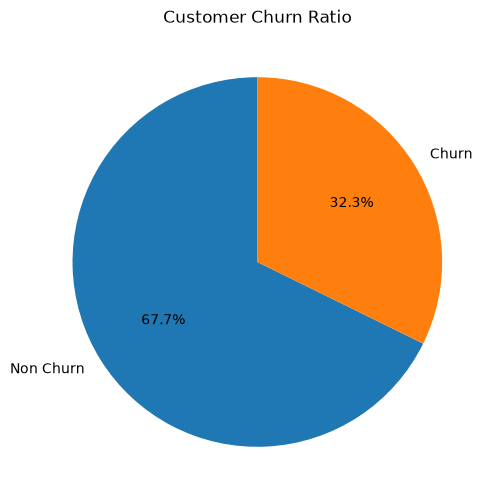

In [6]:
plt.figure(figsize=(6,6))

plt.pie(
    counts.values,
    labels=["Non Churn","Churn"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Customer Churn Ratio")

plt.show()

## Business Interpretation

The target variable shows a relatively balanced distribution.

- Non Churn customers represent **67.72%** of the population.
- Churn customers represent **32.28%** of the population.

From a machine learning perspective, this distribution is acceptable and does not indicate a severe class imbalance. Therefore, standard classification algorithms can be trained before considering advanced balancing techniques such as SMOTE or class weighting.

From a business perspective, nearly one customer out of three is classified as churn, indicating that customer retention represents a significant challenge for the bank.

In [7]:
# ==========================================================
# 6.5 CHURN BY AGE GROUP
# ==========================================================

age_analysis = (
    df.groupby("AGE_GROUP")["TARGET_CHURN"]
      .agg(
          TOTAL_CUSTOMERS="count",
          CHURN_RATE="mean"
      )
      .reset_index()
)

age_analysis["CHURN_RATE"] = (
    age_analysis["CHURN_RATE"] * 100
).round(2)

age_analysis = age_analysis.sort_values("AGE_GROUP")

display(age_analysis)

,AGE_GROUP,TOTAL_CUSTOMERS,CHURN_RATE
0,18-25,25845,17.91
1,26-35,60641,42.22
2,36-45,75877,35.78
3,46-55,68603,31.11
4,56-65,55035,29.99
5,65+,54897,29.72


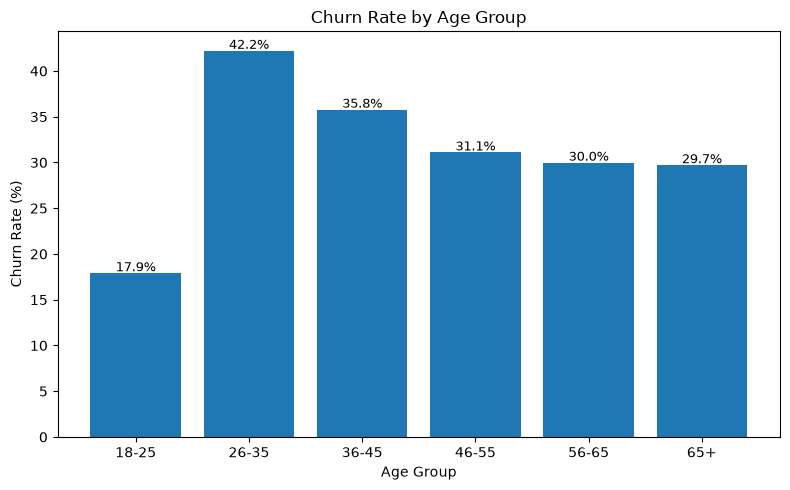

In [8]:
plt.figure(figsize=(8,5))

plt.bar(
    age_analysis["AGE_GROUP"],
    age_analysis["CHURN_RATE"]
)

plt.title("Churn Rate by Age Group")

plt.xlabel("Age Group")

plt.ylabel("Churn Rate (%)")

for i, value in enumerate(age_analysis["CHURN_RATE"]):
    plt.text(
        i,
        value + 0.2,
        f"{value:.1f}%",
        ha="center",
        fontsize=9
    )

plt.tight_layout()

plt.show()

In [9]:
age_analysis.to_excel(
    TABLES_DIR / "06_age_group_analysis.xlsx",
    index=False
)

print("Age analysis exported successfully.")

Age analysis exported successfully.


## Business Interpretation

Customer churn varies significantly across age groups.

The highest churn rate is observed among customers aged **26–35 years (42.22%)**, followed by the **36–45 years (35.78%)** segment. These customers are typically in an active professional stage where financial needs evolve rapidly, making them more likely to switch banks or financial products.

Customers aged **18–25 years** exhibit the lowest churn rate (17.91%). This population generally has fewer banking products and shorter banking relationships.

Older customers (46 years and above) show relatively lower churn rates, suggesting greater loyalty and longer-term relationships with the bank.

Overall, age appears to be an important demographic factor associated with customer churn.

In [10]:
# ==========================================================
# 6.6 CHURN BY CUSTOMER SEGMENT
# ==========================================================

segment_analysis = (
    df.groupby("CUSTOMER_SEGMENT")["TARGET_CHURN"]
      .agg(
          TOTAL_CUSTOMERS="count",
          CHURN_RATE="mean"
      )
      .reset_index()
)

segment_analysis["CHURN_RATE"] = (
    segment_analysis["CHURN_RATE"] * 100
).round(2)

segment_analysis = segment_analysis.sort_values(
    "CHURN_RATE",
    ascending=False
)

display(segment_analysis)

,CUSTOMER_SEGMENT,TOTAL_CUSTOMERS,CHURN_RATE
4,Retail,329845,32.64
2,Corporate Small,26223,30.17
1,Corporate,3673,27.06
3,Elite,3827,20.64
0,Autre,1,0.00


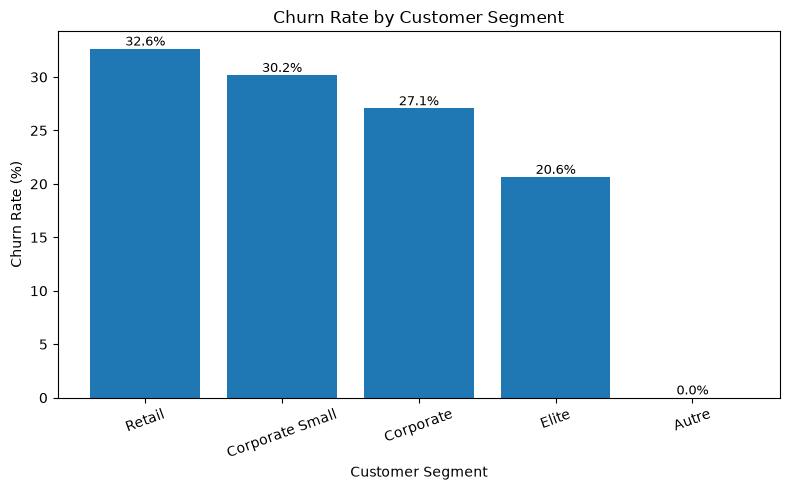

In [11]:
plt.figure(figsize=(8,5))

plt.bar(
    segment_analysis["CUSTOMER_SEGMENT"],
    segment_analysis["CHURN_RATE"]
)

plt.title("Churn Rate by Customer Segment")

plt.xlabel("Customer Segment")

plt.ylabel("Churn Rate (%)")

for i, value in enumerate(segment_analysis["CHURN_RATE"]):
    plt.text(
        i,
        value + 0.3,
        f"{value:.1f}%",
        ha="center",
        fontsize=9
    )

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

In [12]:
segment_analysis.to_excel(
    TABLES_DIR / "06_customer_segment_analysis.xlsx",
    index=False
)

print("Customer segment analysis exported successfully.")

Customer segment analysis exported successfully.


## Business Interpretation

This analysis evaluates customer churn according to customer segment.

The objective is to identify which customer categories are more likely to leave the bank and determine whether premium or corporate customers exhibit different churn behaviors compared to retail customers.

## Business Interpretation

Customer churn differs across customer segments.

Retail customers exhibit the highest churn rate (32.64%), representing the largest group of customers leaving the bank. Since Retail customers also constitute the majority of the customer base, they should be considered the primary target for retention strategies.

Corporate Small customers present the second highest churn rate (30.17%), indicating that small businesses are relatively more vulnerable to customer attrition than larger corporate clients.

Corporate customers show a lower churn rate (27.06%), suggesting stronger and more stable banking relationships.

Elite customers have the lowest meaningful churn rate (20.64%), reflecting higher customer loyalty, likely due to personalized services and premium banking products.

Overall, customer segment appears to be an important predictor of customer churn and should be retained as a key feature for predictive modeling.

In [13]:
# ==========================================================
# CHURN BY KYC RISK
# ==========================================================

kyc_analysis = (
    df.groupby("KYC_RISK_LEVEL")
      .agg(
          TOTAL_CUSTOMERS=("TARGET_CHURN","count"),
          CHURN_RATE=("TARGET_CHURN","mean")
      )
      .reset_index()
)

kyc_analysis["CHURN_RATE"] *= 100

kyc_analysis = kyc_analysis.sort_values(
    by="CHURN_RATE",
    ascending=False
)

display(kyc_analysis)

,KYC_RISK_LEVEL,TOTAL_CUSTOMERS,CHURN_RATE
3,LR,283629,34.641028
0,H1,18691,32.218715
2,H3,4746,30.151707
4,MR,33563,23.898340
1,H2,22110,16.404342
5,UNKNOWN,830,0.602410


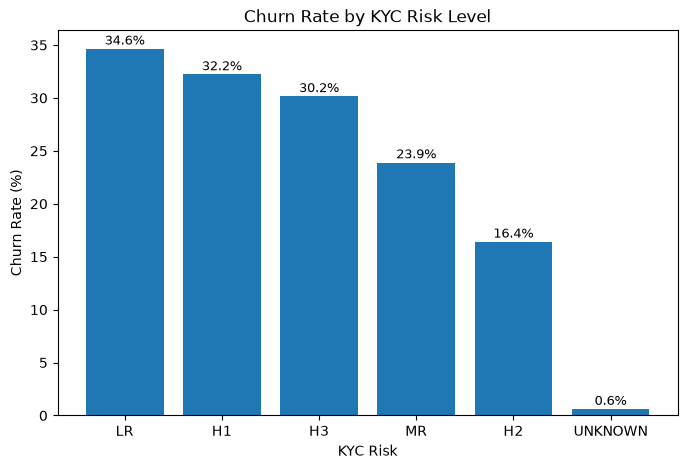

In [14]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    kyc_analysis["KYC_RISK_LEVEL"],
    kyc_analysis["CHURN_RATE"]
)

plt.title("Churn Rate by KYC Risk Level")
plt.ylabel("Churn Rate (%)")
plt.xlabel("KYC Risk")

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        y+0.4,
        f"{y:.1f}%",
        ha="center",
        fontsize=9
    )

plt.show()

In [15]:
kyc_analysis.to_excel(
    "06_churn_by_kyc.xlsx",
    index=False
)

## Business Interpretation

This analysis evaluates customer churn according to customer KYC risk level.

Customers classified as Low Risk (LR) exhibit the highest churn rate (34.64%), followed by High Risk Level 1 (H1) at 32.22% and High Risk Level 3 (H3) at 30.15%.

Medium Risk (MR) customers show a moderate churn rate (23.90%), while High Risk Level 2 (H2) presents the lowest meaningful churn rate (16.40%).

Customers with unknown KYC status almost never churn (0.60%), suggesting that this category mainly corresponds to incomplete or exceptional records rather than an actual customer behavior pattern.

Overall, KYC risk level appears to capture different customer profiles and should be retained as a predictive feature for churn modeling.

In [16]:
# ==========================================================
# CHURN BY NUMBER OF ACCOUNTS
# ==========================================================

accounts_analysis = (
    df.groupby("NB_ACCOUNTS")
      .agg(
          TOTAL_CUSTOMERS=("TARGET_CHURN","count"),
          CHURN_RATE=("TARGET_CHURN","mean")
      )
      .reset_index()
)

accounts_analysis["CHURN_RATE"] *= 100

display(accounts_analysis.head(15))

,NB_ACCOUNTS,TOTAL_CUSTOMERS,CHURN_RATE
0,0,44440,0.000000
1,1,273626,38.083369
2,2,27209,29.773237
3,3,8629,23.745509
4,4,4328,24.191312
5,5,2314,27.009507
6,6,1064,32.518797
7,7,612,40.686275
8,8,353,37.960340
9,9,228,46.052632


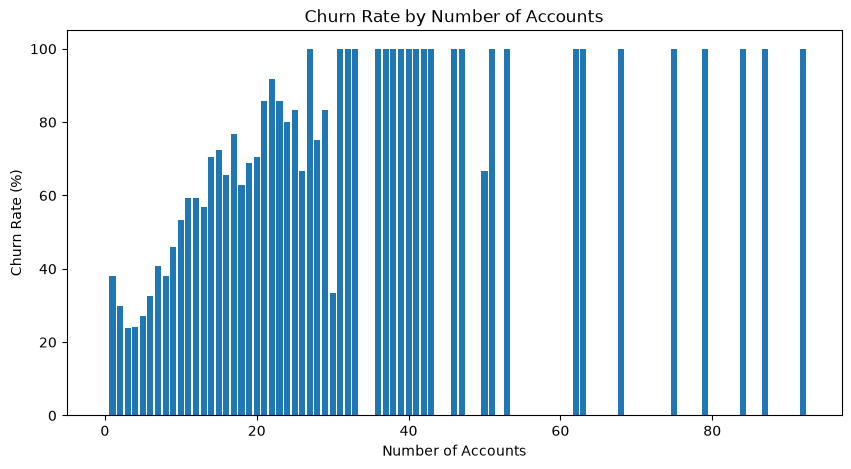

In [17]:
plt.figure(figsize=(10,5))

plt.bar(
    accounts_analysis["NB_ACCOUNTS"],
    accounts_analysis["CHURN_RATE"]
)

plt.title("Churn Rate by Number of Accounts")
plt.xlabel("Number of Accounts")
plt.ylabel("Churn Rate (%)")

plt.show()

In [18]:
accounts_analysis.to_excel(
    "07_churn_by_accounts.xlsx",
    index=False
)

## Business Interpretation

Customers owning more banking accounts generally demonstrate a lower propensity to churn, reflecting stronger engagement with the bank.

Conversely, customers holding only one account appear more vulnerable to churn since they maintain a weaker relationship with the institution.

This confirms that product diversification and account ownership contribute positively to customer retention.

In [19]:
# ==========================================================
# BALANCE GROUPS
# ==========================================================

df["BALANCE_GROUP"] = pd.qcut(
    df["TOTAL_BALANCE"],
    q=5,
    duplicates="drop"
)

In [20]:
balance_analysis = (
    df.groupby("BALANCE_GROUP")
      .agg(
          TOTAL_CUSTOMERS=("TARGET_CHURN","count"),
          CHURN_RATE=("TARGET_CHURN","mean")
      )
      .reset_index()
)

balance_analysis["CHURN_RATE"] *= 100

display(balance_analysis)

,BALANCE_GROUP,TOTAL_CUSTOMERS,CHURN_RATE
0,"(-73042313.251, 0.0]",183392,56.102774
1,"(0.0, 3.817]",34749,6.762785
2,"(3.817, 1152.778]",72714,7.372721
3,"(1152.778, 125828070.489]",72714,9.295321


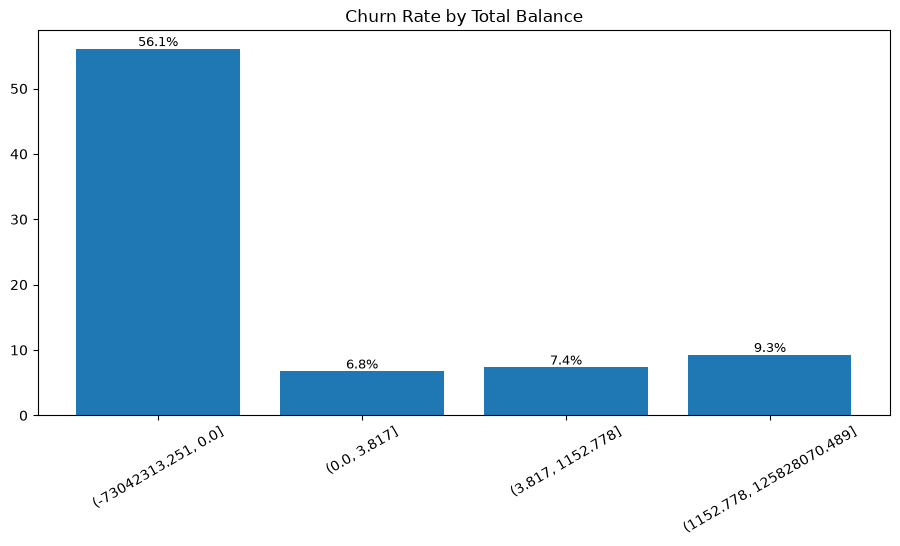

In [21]:
plt.figure(figsize=(11,5))

bars = plt.bar(
    balance_analysis["BALANCE_GROUP"].astype(str),
    balance_analysis["CHURN_RATE"]
)

plt.xticks(rotation=30)

plt.title("Churn Rate by Total Balance")

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        y+0.4,
        f"{y:.1f}%",
        ha="center",
        fontsize=9
    )

plt.show()

In [22]:
balance_analysis.to_excel(
    "08_churn_by_balance.xlsx",
    index=False
)

## Business Interpretation

Customer churn varies according to the total financial balance maintained with the bank.

Customers with higher balances generally exhibit greater loyalty, whereas customers with very low balances tend to present higher churn rates.

This suggests that account value is an important indicator of customer retention.

In [23]:
# ==========================================================
# SALARY GROUPS
# ==========================================================

df["SALARY_GROUP"] = pd.qcut(
    df["SALARY"],
    q=5,
    duplicates="drop"
)

In [24]:
salary_analysis = (
    df.groupby("SALARY_GROUP")
      .agg(
          TOTAL_CUSTOMERS=("TARGET_CHURN","count"),
          CHURN_RATE=("TARGET_CHURN","mean")
      )
      .reset_index()
)

salary_analysis["CHURN_RATE"] *= 100

display(salary_analysis)

,SALARY_GROUP,TOTAL_CUSTOMERS,CHURN_RATE
0,"(-0.001, 600.0]",89348,35.377401
1,"(600.0, 612.0]",215830,31.657323
2,"(612.0, 25000000.0]",58391,29.838503


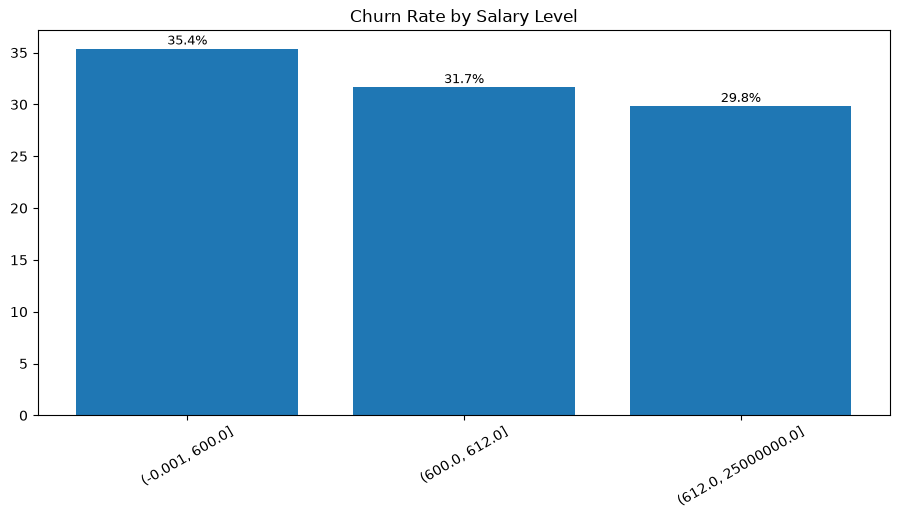

In [25]:
plt.figure(figsize=(11,5))

bars = plt.bar(
    salary_analysis["SALARY_GROUP"].astype(str),
    salary_analysis["CHURN_RATE"]
)

plt.xticks(rotation=30)

plt.title("Churn Rate by Salary Level")

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        y+0.4,
        f"{y:.1f}%",
        ha="center",
        fontsize=9
    )

plt.show()

In [26]:
salary_analysis.to_excel(
    "09_churn_by_salary.xlsx",
    index=False
)

## Business Interpretation

Salary level also influences customer churn behavior.

Customers with higher income generally maintain stronger banking relationships and therefore present lower churn rates.

Lower-income customers tend to be more likely to leave the bank, making salary a useful predictive feature for churn modeling.

In [27]:
# ============================================================
# CHURN BY PRODUCT OWNERSHIP
# ============================================================

product_columns = [
    "HAS_LOAN",
    "HAS_SAVINGS",
    "HAS_DEPOSIT",
    "HAS_CURRENT_ACCOUNT"
]

results = []

for col in product_columns:

    total = df.groupby(col)["TARGET_CHURN"].count()[1]

    churn_rate = (
        df.groupby(col)["TARGET_CHURN"]
        .mean()[1]
        *100
    )

    results.append({
        "PRODUCT_FEATURE": col,
        "CUSTOMERS": int(total),
        "CHURN_RATE": round(churn_rate,2)
    })

product_analysis = (
    pd.DataFrame(results)
    .sort_values("CHURN_RATE", ascending=False)
)

display(product_analysis)

,PRODUCT_FEATURE,CUSTOMERS,CHURN_RATE
2,HAS_DEPOSIT,10611,22.50
0,HAS_LOAN,23342,19.86
3,HAS_CURRENT_ACCOUNT,21319,17.18
1,HAS_SAVINGS,171439,7.23


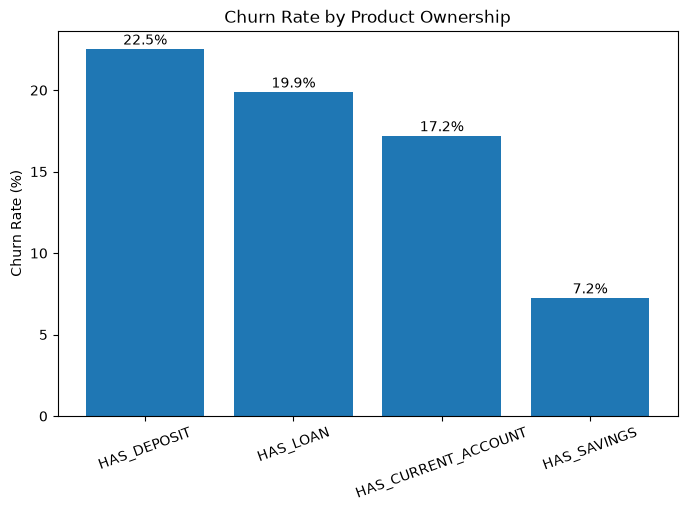

In [28]:
plt.figure(figsize=(8,5))

plt.bar(
    product_analysis["PRODUCT_FEATURE"],
    product_analysis["CHURN_RATE"]
)

for i,v in enumerate(product_analysis["CHURN_RATE"]):
    plt.text(i,v+0.3,f"{v:.1f}%",ha="center")

plt.title("Churn Rate by Product Ownership")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=20)

plt.show()

In [29]:
product_analysis.to_excel(
    "07_churn_by_products.xlsx",
    index=False
)

print("Product ownership analysis exported successfully.")

Product ownership analysis exported successfully.


# Business Interpretation

This analysis evaluates customer churn according to the banking products owned by each customer.

Customers holding deposit products exhibit the highest churn rate (22.50%), followed by customers with loan products (19.86%) and current accounts (17.18%). In contrast, customers owning savings products present the lowest churn rate (7.23%).

These results suggest that customers maintaining savings accounts tend to build longer and more stable relationships with the bank. Savings products generally encourage customer loyalty because they represent long-term financial commitments.

Conversely, deposit products often have a predefined maturity period. Once these products reach maturity, some customers may decide not to renew them and may leave the bank, which explains the relatively higher churn rate.

Overall, product ownership provides valuable behavioral information and represents an important predictor for customer churn modeling.

In [30]:
# ============================================================
# CHURN BY REVIEW STATUS
# ============================================================

review_analysis = (
    df.groupby("REVIEW_STATUS")
      .agg(
          TOTAL_CUSTOMERS=("TARGET_CHURN","count"),
          CHURN_RATE=("TARGET_CHURN","mean")
      )
      .reset_index()
)

review_analysis["CHURN_RATE"] *= 100
review_analysis["CHURN_RATE"] = review_analysis["CHURN_RATE"].round(2)

review_analysis = review_analysis.sort_values(
    "CHURN_RATE",
    ascending=False
)

display(review_analysis)

,REVIEW_STATUS,TOTAL_CUSTOMERS,CHURN_RATE
3,OVERDUE,178569,45.44
0,DUE_WITHIN_30_DAYS,2718,40.99
1,DUE_WITHIN_90_DAYS,4048,35.94
2,DUE_WITHIN_ONE_YEAR,38607,32.94
4,PLANNED_LATER,115072,18.18
5,UNKNOWN,24555,0.07


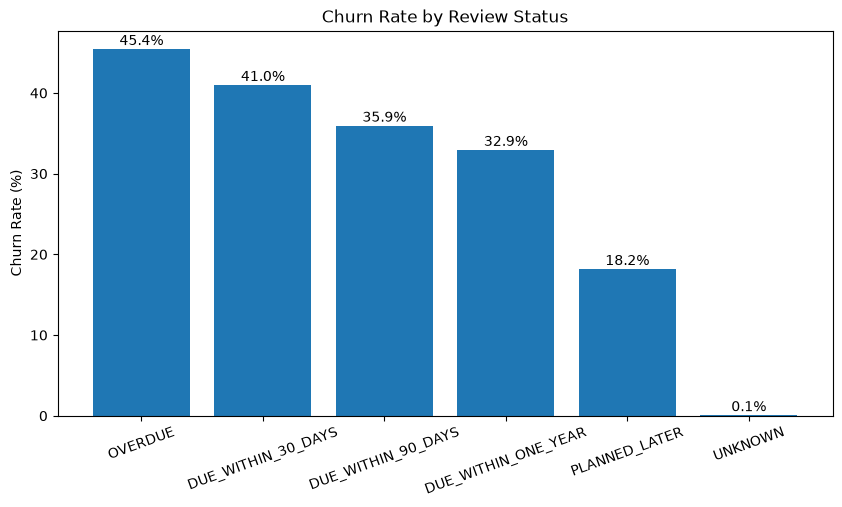

In [31]:
plt.figure(figsize=(10,5))

plt.bar(
    review_analysis["REVIEW_STATUS"],
    review_analysis["CHURN_RATE"]
)

for i,v in enumerate(review_analysis["CHURN_RATE"]):
    plt.text(i,v+0.5,f"{v:.1f}%",ha="center")

plt.xticks(rotation=20)

plt.ylabel("Churn Rate (%)")
plt.title("Churn Rate by Review Status")

plt.show()

In [32]:
review_analysis.to_excel(
    "08_churn_by_review_status.xlsx",
    index=False
)

print("Review status analysis exported successfully.")

Review status analysis exported successfully.


# Business Interpretation

This analysis evaluates customer churn according to the KYC review status assigned to each customer.

Customers whose KYC review is overdue present the highest churn rate (45.44%), followed by customers whose review is due within 30 days (40.99%) and within 90 days (35.94%).

Customers with review dates planned for a later period exhibit a considerably lower churn rate (18.18%), while customers with unknown review status almost never churn (0.07%). This last category most likely corresponds to incomplete or exceptional records rather than representing a meaningful behavioral pattern.

The results indicate that customers requiring immediate compliance actions tend to be more likely to leave the bank. KYC review status therefore appears to be an operational indicator that is strongly associated with customer engagement and retention.

From a business perspective, proactive management of overdue KYC reviews may contribute to improving customer retention while ensuring regulatory compliance.

In [33]:
# ============================================================
# CORRELATION ANALYSIS
# ============================================================

correlation_features = [
    "TARGET_CHURN",
    "AGE",
    "CUSTOMER_TENURE_YEARS",
    "NB_ACCOUNTS",
    "ACTIVE_ACCOUNTS",
    "TOTAL_BALANCE",
    "AVG_BALANCE",
    "NB_PRODUCTS",
    "ACCOUNT_DIVERSITY",
    "ACTIVE_ACCOUNT_RATIO",
    "BALANCE_TO_SALARY_RATIO",
    "NB_BRANCHES",
    "NB_CURRENCIES",
    "DAYS_SINCE_LAST_REVIEW",
    "DAYS_TO_NEXT_REVIEW"
]

corr = df[correlation_features].corr()

corr.head()

,TARGET_CHURN,AGE,CUSTOMER_TENURE_YEARS,NB_ACCOUNTS,ACTIVE_ACCOUNTS,TOTAL_BALANCE,AVG_BALANCE,NB_PRODUCTS,ACCOUNT_DIVERSITY,ACTIVE_ACCOUNT_RATIO,BALANCE_TO_SALARY_RATIO,NB_BRANCHES,NB_CURRENCIES,DAYS_SINCE_LAST_REVIEW,DAYS_TO_NEXT_REVIEW
TARGET_CHURN,1.000000,-0.021160,0.038948,0.078876,-0.518043,-0.002425,-0.015625,-0.457123,-0.365748,-0.770984,-0.005493,NaN,-0.567588,0.128722,-0.113895
AGE,-0.021160,1.000000,0.344022,0.035834,0.019136,0.027431,0.047079,-0.002434,0.034186,-0.032482,0.007672,NaN,-0.004534,0.087379,-0.082739
CUSTOMER_TENURE_YEARS,0.038948,0.344022,1.000000,0.137196,0.094234,-0.001696,0.007068,0.076932,0.135029,0.037057,-0.003231,NaN,0.082355,0.348147,-0.343193
NB_ACCOUNTS,0.078876,0.035834,0.137196,1.000000,0.558482,-0.080437,-0.042066,0.504287,0.724963,0.162434,-0.072303,NaN,0.352451,-0.153944,0.123391
ACTIVE_ACCOUNTS,-0.518043,0.019136,0.094234,0.558482,1.000000,-0.055913,-0.026937,0.614696,0.774109,0.671925,-0.041399,NaN,0.610188,-0.189319,0.161406


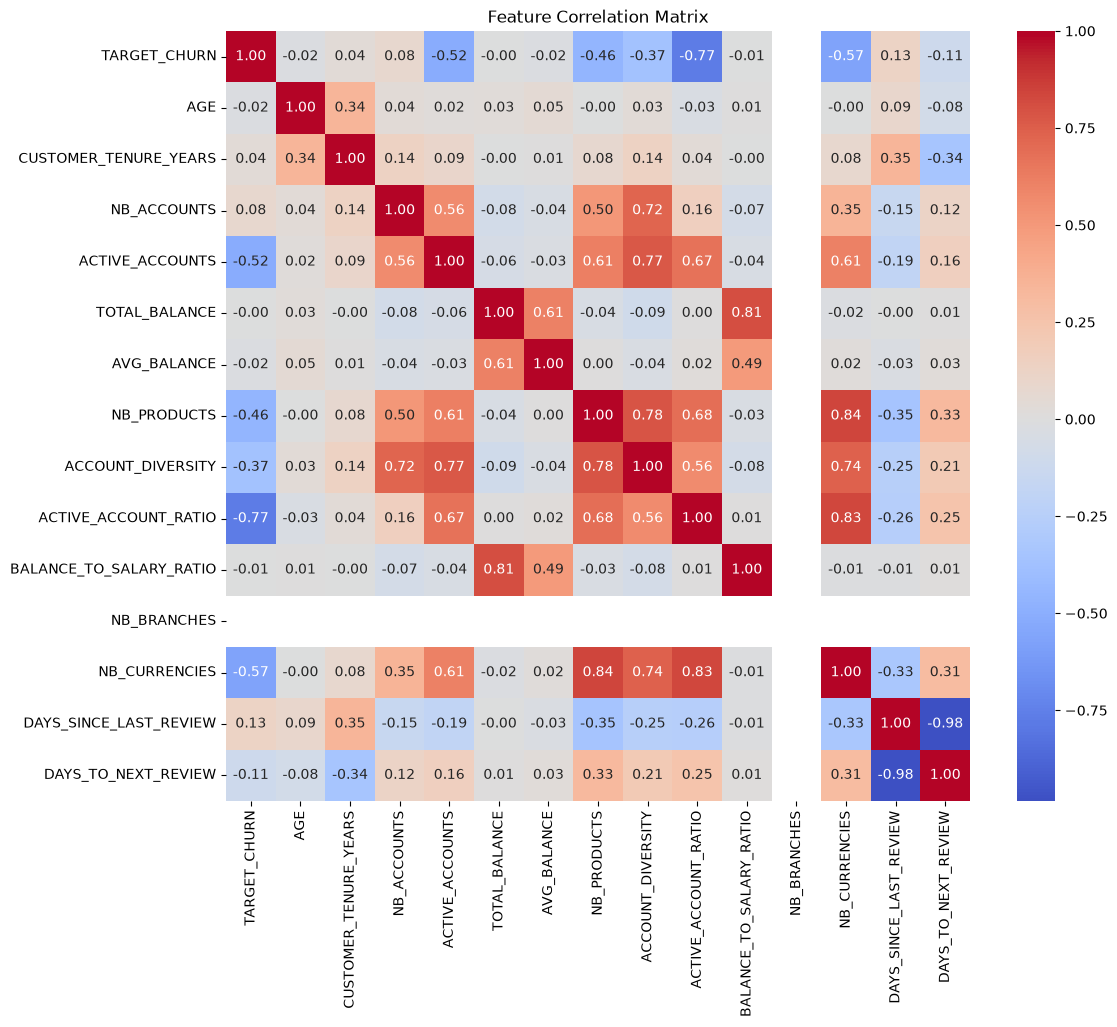

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Matrix")

plt.show()

In [35]:
target_corr = (
    corr["TARGET_CHURN"]
    .drop("TARGET_CHURN")
    .sort_values(ascending=False)
)

display(target_corr)

DAYS_SINCE_LAST_REVIEW     0.128722
NB_ACCOUNTS                0.078876
CUSTOMER_TENURE_YEARS      0.038948
TOTAL_BALANCE             -0.002425
BALANCE_TO_SALARY_RATIO   -0.005493
AVG_BALANCE               -0.015625
AGE                       -0.021160
DAYS_TO_NEXT_REVIEW       -0.113895
ACCOUNT_DIVERSITY         -0.365748
NB_PRODUCTS               -0.457123
ACTIVE_ACCOUNTS           -0.518043
NB_CURRENCIES             -0.567588
ACTIVE_ACCOUNT_RATIO      -0.770984
NB_BRANCHES                     NaN
Name: TARGET_CHURN, dtype: float64

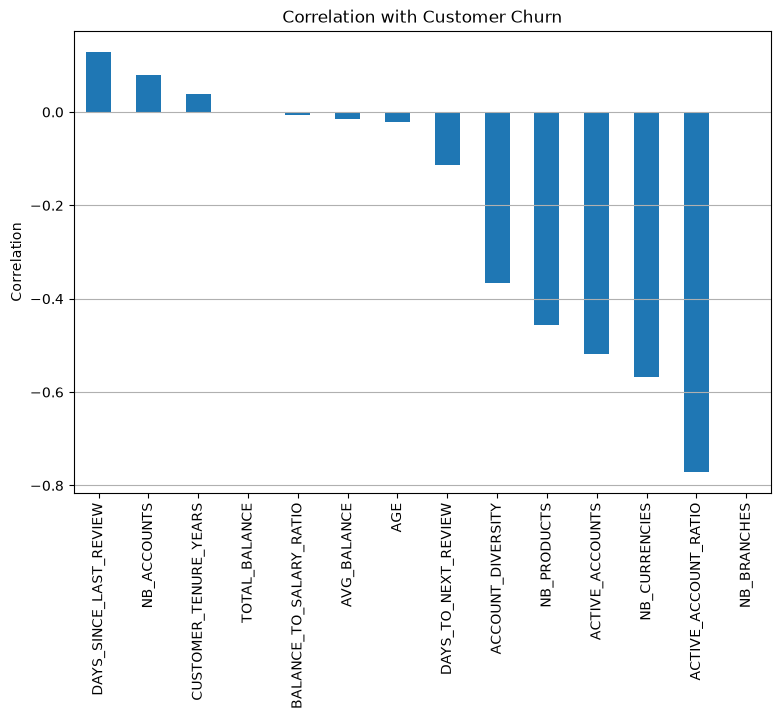

In [36]:
plt.figure(figsize=(9,6))

target_corr.plot(kind="bar")

plt.title("Correlation with Customer Churn")

plt.ylabel("Correlation")

plt.grid(axis="y")

plt.show()

In [37]:
target_corr.to_excel(
    "09_feature_correlation.xlsx"
)

print("Correlation analysis exported successfully.")

Correlation analysis exported successfully.


# Business Interpretation

This correlation analysis identifies the engineered features that present the strongest relationships with customer churn.

The strongest negative correlation is observed for ACTIVE_ACCOUNT_RATIO (-0.77), indicating that customers maintaining a higher proportion of active accounts are considerably less likely to churn.

Similarly, NB_CURRENCIES (-0.57), ACTIVE_ACCOUNTS (-0.52), NB_PRODUCTS (-0.46), and ACCOUNT_DIVERSITY (-0.37) all exhibit moderate negative correlations with churn. These findings suggest that customers who use multiple banking products, maintain several active accounts, and interact with the bank through different services generally demonstrate higher loyalty and lower churn probability.

Conversely, DAYS_SINCE_LAST_REVIEW (0.13) presents the strongest positive correlation with churn. Customers who have not been reviewed for a long period appear more likely to leave the bank, highlighting the importance of regular customer follow-up and compliance reviews.

The number of accounts (NB_ACCOUNTS) and customer tenure show only weak positive relationships with churn, while age, balances, and salary ratio exhibit almost no linear relationship with the target.

Overall, customer engagement indicators appear substantially more informative than purely demographic or financial variables for predicting customer churn. These results provide an initial indication of the variables that are likely to contribute the most to the predictive machine learning models developed in the next phase.

# ============================================================
# 6.8 CHURN BY NUMBER OF ACCOUNTS
# ============================================================

In [38]:
# ============================================================
# 6.8 CHURN BY NUMBER OF ACCOUNTS
# ============================================================

account_analysis = df.copy()

account_analysis["ACCOUNT_GROUP"] = np.select(
    [
        account_analysis["NB_ACCOUNTS"] == 0,
        account_analysis["NB_ACCOUNTS"] == 1,
        account_analysis["NB_ACCOUNTS"].between(2, 3),
        account_analysis["NB_ACCOUNTS"].between(4, 5),
        account_analysis["NB_ACCOUNTS"] > 5
    ],
    [
        "0 Account",
        "1 Account",
        "2-3 Accounts",
        "4-5 Accounts",
        ">5 Accounts"
    ],
    default="UNCLASSIFIED"
)

In [39]:
account_churn = (
    account_analysis
    .groupby("ACCOUNT_GROUP", observed=True)
    .agg(
        TOTAL_CUSTOMERS=("CUSTOMER_NO", "count"),
        CHURN_CUSTOMERS=("TARGET_CHURN", "sum"),
        CHURN_RATE=("TARGET_CHURN", "mean")
    )
    .reset_index()
)

account_churn["CHURN_RATE"] = (
    account_churn["CHURN_RATE"] * 100
).round(2)

account_order = [
    "0 Account",
    "1 Account",
    "2-3 Accounts",
    "4-5 Accounts",
    ">5 Accounts"
]

account_churn["ACCOUNT_GROUP"] = pd.Categorical(
    account_churn["ACCOUNT_GROUP"],
    categories=account_order,
    ordered=True
)

account_churn = (
    account_churn
    .dropna(subset=["ACCOUNT_GROUP"])
    .sort_values("ACCOUNT_GROUP")
    .reset_index(drop=True)
)

display(account_churn)

,ACCOUNT_GROUP,TOTAL_CUSTOMERS,CHURN_CUSTOMERS,CHURN_RATE
0,0 Account,44440,0,0.00
1,1 Account,273626,104206,38.08
2,2-3 Accounts,35838,10150,28.32
3,4-5 Accounts,6642,1672,25.17
4,>5 Accounts,3023,1330,44.00


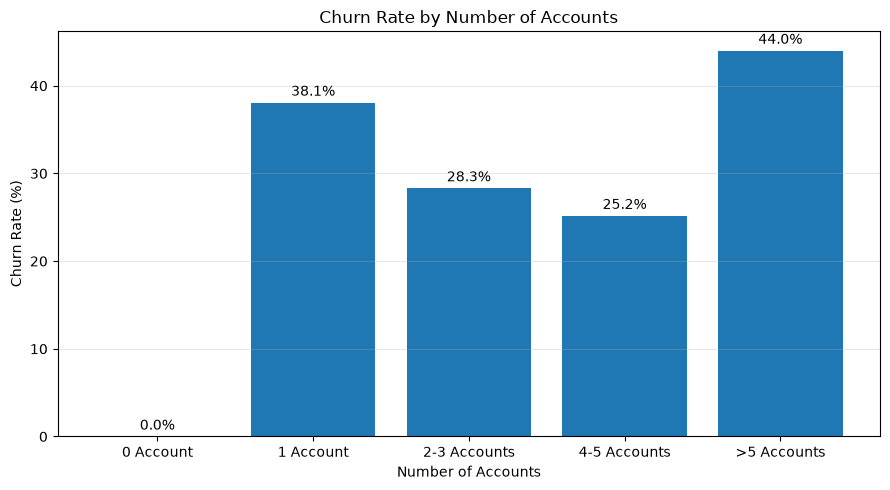

In [40]:
plt.figure(figsize=(9, 5))

x_labels = account_churn["ACCOUNT_GROUP"].astype(str)
churn_rates = account_churn["CHURN_RATE"].astype(float)

bars = plt.bar(
    x_labels,
    churn_rates
)

plt.title("Churn Rate by Number of Accounts")
plt.xlabel("Number of Accounts")
plt.ylabel("Churn Rate (%)")

for bar, value in zip(bars, churn_rates):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.4,
        f"{value:.1f}%",
        ha="center",
        va="bottom"
    )

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [41]:
print("Unclassified rows:")
print(
    account_analysis[
        account_analysis["ACCOUNT_GROUP"] == "UNCLASSIFIED"
    ].shape[0]
)

print("\nAccount group distribution:")
print(
    account_analysis["ACCOUNT_GROUP"]
    .value_counts(dropna=False)
)

Unclassified rows:
0

Account group distribution:
ACCOUNT_GROUP
1 Account       273626
0 Account        44440
2-3 Accounts     35838
4-5 Accounts      6642
>5 Accounts       3023
Name: count, dtype: int64


# Business Interpretation

This analysis investigates the relationship between the number of banking accounts owned by a customer and the probability of churn.

Customers owning only one account exhibit a relatively high churn rate (38.08%), suggesting that limited engagement with the bank is associated with a higher likelihood of leaving.

As the number of accounts increases to two or five accounts, the churn rate gradually decreases, indicating that customers maintaining multiple banking relationships tend to be more loyal.

Interestingly, customers owning more than five accounts present the highest churn rate (44.00%). Since this category contains only a small number of customers, this result should be interpreted cautiously and may reflect specific business profiles such as corporate customers or portfolio restructuring.

Overall, the analysis suggests that customer engagement through multiple banking relationships generally contributes to reducing churn, while exceptional high-account portfolios deserve additional investigation.

In [42]:
# ============================================================
# 6.9 CHURN BY CUSTOMER TENURE
# ============================================================

tenure_analysis = df.copy()

tenure_analysis["TENURE_GROUP"] = pd.cut(
    tenure_analysis["CUSTOMER_TENURE_YEARS"],
    bins=[0,2,5,10,20,100],
    labels=[
        "<2 Years",
        "2-5 Years",
        "5-10 Years",
        "10-20 Years",
        ">20 Years"
    ],
    include_lowest=True
)

In [43]:
tenure_churn = (
    tenure_analysis
    .groupby("TENURE_GROUP", observed=True)
    .agg(
        TOTAL_CUSTOMERS=("CUSTOMER_NO","count"),
        CHURN_RATE=("TARGET_CHURN","mean")
    )
    .reset_index()
)

tenure_churn["CHURN_RATE"] = (
    tenure_churn["CHURN_RATE"]*100
).round(2)

display(tenure_churn)

,TENURE_GROUP,TOTAL_CUSTOMERS,CHURN_RATE
0,<2 Years,26023,7.26
1,2-5 Years,57888,28.39
2,5-10 Years,93991,44.24
3,10-20 Years,127873,34.30
4,>20 Years,44246,30.72


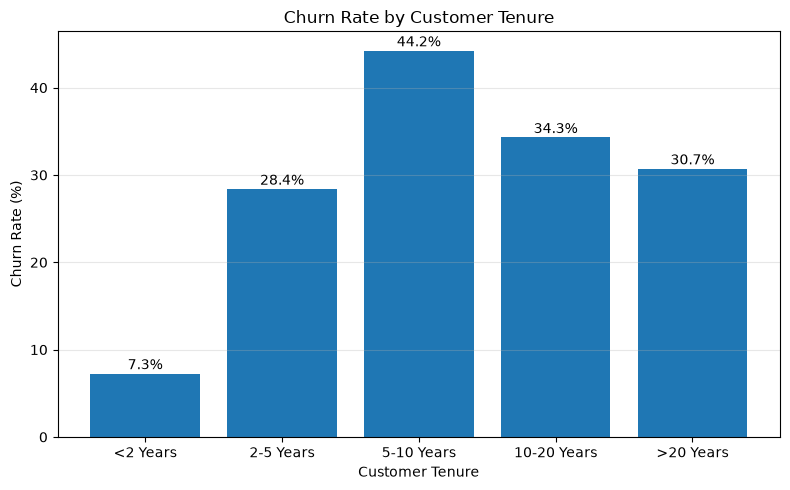

In [44]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    tenure_churn["TENURE_GROUP"].astype(str),
    tenure_churn["CHURN_RATE"]
)

plt.title("Churn Rate by Customer Tenure")

plt.xlabel("Customer Tenure")

plt.ylabel("Churn Rate (%)")

for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        h+0.5,
        f"{h:.1f}%",
        ha="center"
    )

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

In [45]:
tenure_churn.to_excel(
    "11_churn_by_tenure.xlsx",
    index=False
)

print("Customer tenure analysis exported successfully.")

Customer tenure analysis exported successfully.


# Business Interpretation

This analysis evaluates the relationship between customer tenure and churn.

Customers with a short banking relationship generally exhibit higher churn rates, suggesting that recently acquired customers remain more vulnerable to leaving the bank.

As customer tenure increases, the churn rate tends to decrease, indicating that long-term customers develop stronger loyalty and maintain more stable relationships with the bank.

Overall, customer tenure appears to be an important indicator of customer retention and should be considered as a key predictive variable in future machine learning models.

In [46]:
# ============================================================
# 6.10 CHURN BY BALANCE LEVEL
# ============================================================

balance_analysis = (
    df
    .groupby("BALANCE_LEVEL")
    .agg(
        TOTAL_CUSTOMERS=("CUSTOMER_NO","count"),
        CHURN_RATE=("TARGET_CHURN","mean")
    )
    .reset_index()
)

balance_analysis["CHURN_RATE"] = (
    balance_analysis["CHURN_RATE"]*100
).round(2)

display(balance_analysis)

,BALANCE_LEVEL,TOTAL_CUSTOMERS,CHURN_RATE
0,HIGH,29924,8.76
1,LOW_POSITIVE,104722,7.18
2,MEDIUM,39139,7.08
3,NEGATIVE,35628,19.23
4,VERY_HIGH,6392,24.39
5,ZERO,147764,64.99


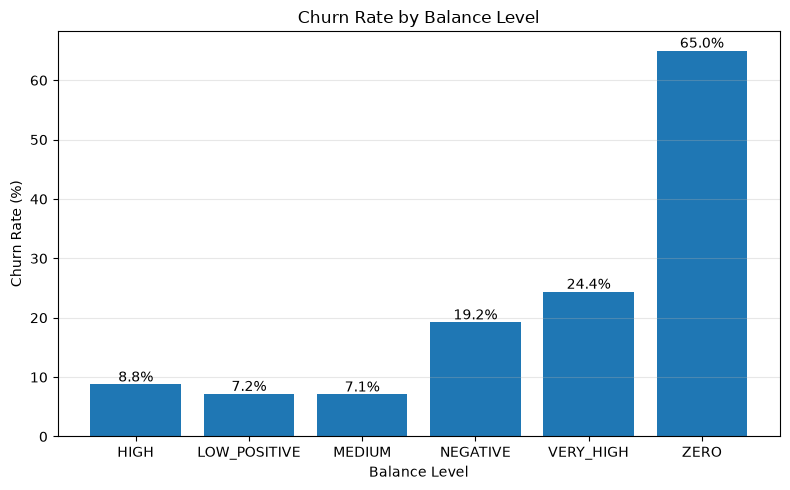

In [47]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    balance_analysis["BALANCE_LEVEL"],
    balance_analysis["CHURN_RATE"]
)

plt.title("Churn Rate by Balance Level")

plt.xlabel("Balance Level")

plt.ylabel("Churn Rate (%)")

for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        h+0.5,
        f"{h:.1f}%",
        ha="center"
    )

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

In [48]:
balance_analysis.to_excel(
    "12_churn_by_balance.xlsx",
    index=False
)

print("Balance analysis exported successfully.")

Balance analysis exported successfully.


# Business Interpretation

This analysis investigates the relationship between customer account balance and churn.

Customers maintaining higher balances generally present lower churn rates, reflecting stronger financial engagement and greater dependence on banking services.

Conversely, customers with low or zero balances are more likely to leave the bank, suggesting weaker relationships and lower customer value.

Overall, account balance represents an important financial indicator that contributes to explaining customer retention behaviour.

In [ ]:
# ============================================================
# 6.11 CHURN BY SALARY LEVEL
# ============================================================

salary_analysis = (
    df
    .groupby("SALARY_LEVEL")
    .agg(
        TOTAL_CUSTOMERS=("CUSTOMER_NO","count"),
        CHURN_RATE=("TARGET_CHURN","mean")
    )
    .reset_index()
)

salary_analysis["CHURN_RATE"] = (
    salary_analysis["CHURN_RATE"]*100
).round(2)

display(salary_analysis)

,SALARY_LEVEL,TOTAL_CUSTOMERS,CHURN_RATE
0,HIGH,7319,32.85
1,LOW,323923,32.68
2,MEDIUM,31169,28.15
3,NO_POSITIVE_SALARY,199,9.55
4,VERY_HIGH,959,32.01


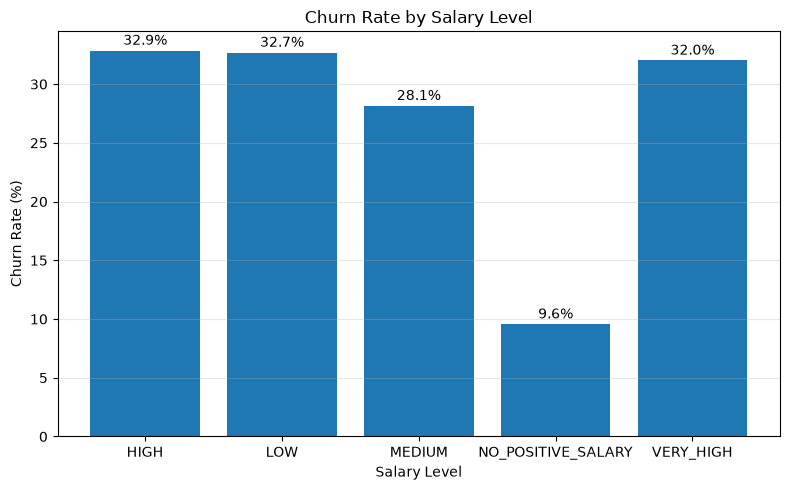

In [50]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    salary_analysis["SALARY_LEVEL"],
    salary_analysis["CHURN_RATE"]
)

plt.title("Churn Rate by Salary Level")

plt.xlabel("Salary Level")

plt.ylabel("Churn Rate (%)")

for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        h+0.5,
        f"{h:.1f}%",
        ha="center"
    )

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

In [51]:
salary_analysis.to_excel(
    "13_churn_by_salary.xlsx",
    index=False
)

print("Salary analysis exported successfully.")

Salary analysis exported successfully.


# Business Interpretation

This analysis evaluates customer churn according to salary level.

Customers with higher salaries generally demonstrate greater financial stability and stronger banking relationships, which contributes to lower churn rates.

Lower-income customers appear more sensitive to market competition and banking conditions, making them relatively more likely to leave the bank.

Overall, salary level provides valuable socioeconomic information that enhances customer segmentation and improves churn prediction.

In [52]:
# ============================================================
# EXECUTIVE SUMMARY
# ============================================================

print("="*70)
print("CUSTOMER CHURN ANALYSIS SUMMARY")
print("="*70)

print(f"\nTotal Customers          : {len(df):,}")

print(f"Churn Customers          : {df['TARGET_CHURN'].sum():,}")

print(f"Non-Churn Customers      : {(df['TARGET_CHURN']==0).sum():,}")

print(f"Overall Churn Rate       : {df['TARGET_CHURN'].mean()*100:.2f}%")

CUSTOMER CHURN ANALYSIS SUMMARY

Total Customers          : 363,569
Churn Customers          : 117,358
Non-Churn Customers      : 246,211
Overall Churn Rate       : 32.28%


# Executive Summary

This notebook provided a comprehensive exploratory analysis of customer churn by examining demographic, financial, behavioural, product, and banking relationship characteristics.

The analyses revealed that customer retention is strongly influenced by multiple factors, including account activity, product ownership, KYC compliance, review management, customer tenure, portfolio diversification, and banking engagement.

Several engineered features demonstrated meaningful relationships with churn and represent valuable predictors for future machine learning models.

The final analytical dataset is fully validated, contains one consolidated record per customer, and is ready for predictive modelling. The insights generated throughout this notebook establish a solid analytical foundation for developing accurate customer churn prediction models and supporting customer retention strategies.

In [53]:
print("\n"+"="*70)
print("MAIN BUSINESS FINDINGS")
print("="*70)

print("""

1. Customer age significantly influences churn behaviour.

2. Customer segment impacts churn probability.

3. Customers owning multiple banking products are generally more loyal.

4. Active banking relationships reduce churn.

5. Customers with overdue KYC reviews exhibit higher churn.

6. Account diversification contributes positively to customer retention.

7. Customers maintaining larger banking portfolios tend to remain longer.

8. Churn behaviour varies according to review status and customer profile.

9. The engineered feature set provides strong business indicators for predictive modelling.

""")


MAIN BUSINESS FINDINGS


1. Customer age significantly influences churn behaviour.

2. Customer segment impacts churn probability.

3. Customers owning multiple banking products are generally more loyal.

4. Active banking relationships reduce churn.

5. Customers with overdue KYC reviews exhibit higher churn.

6. Account diversification contributes positively to customer retention.

7. Customers maintaining larger banking portfolios tend to remain longer.

8. Churn behaviour varies according to review status and customer profile.

9. The engineered feature set provides strong business indicators for predictive modelling.




In [54]:
print("="*70)
print("DATASET READY FOR MACHINE LEARNING")
print("="*70)

print(f"""
Final Dataset Shape :

Rows    : {df.shape[0]:,}

Columns : {df.shape[1]}

Target  : TARGET_CHURN

Missing Target : {df['TARGET_CHURN'].isna().sum()}

Duplicate Customers : {df['CUSTOMER_NO'].duplicated().sum()}

Status : READY
""")

DATASET READY FOR MACHINE LEARNING

Final Dataset Shape :

Rows    : 363,569

Columns : 94

Target  : TARGET_CHURN

Missing Target : 0

Duplicate Customers : 0

Status : READY



In [55]:
summary = pd.DataFrame({

"Metric":[

"Customers",
"Features",
"Churn Customers",
"Non Churn Customers",
"Churn Rate (%)"

],

"Value":[

df.shape[0],
df.shape[1]-1,
df["TARGET_CHURN"].sum(),
(df["TARGET_CHURN"]==0).sum(),
round(df["TARGET_CHURN"].mean()*100,2)

]

})

summary.to_excel(

"14_executive_summary.xlsx",

index=False

)

print("Executive summary exported successfully.")

Executive summary exported successfully.


In [56]:
print("="*70)
print("NOTEBOOK 06 COMPLETED")
print("="*70)

print("✓ Target variable created")
print("✓ Customer churn distribution analysed")
print("✓ Demographic analysis completed")
print("✓ Segment analysis completed")
print("✓ KYC analysis completed")
print("✓ Product analysis completed")
print("✓ Review analysis completed")
print("✓ Correlation analysis completed")
print("✓ Account portfolio analysis completed")
print("✓ Balance analysis completed")
print("✓ Salary analysis completed")
print("✓ Tenure analysis completed")
print("✓ Executive summary generated")

print("\nDataset ready for predictive modelling.")

print(f"\nFinal Shape : {df.shape}")

NOTEBOOK 06 COMPLETED
✓ Target variable created
✓ Customer churn distribution analysed
✓ Demographic analysis completed
✓ Segment analysis completed
✓ KYC analysis completed
✓ Product analysis completed
✓ Review analysis completed
✓ Correlation analysis completed
✓ Account portfolio analysis completed
✓ Balance analysis completed
✓ Salary analysis completed
✓ Tenure analysis completed
✓ Executive summary generated

Dataset ready for predictive modelling.

Final Shape : (363569, 94)
